# Multimodal RAG: Beyond Text RAG
### Classroom session — 30–40 minutes | 100% Free & Local (Ollama, no API keys)

You already know **basic RAG**: PDF → text chunks → embeddings → FAISS → LLM → answer.

Today we extend that pipeline to handle **tables** and **images/diagrams**, not just plain text.

## Traditional RAG (what you already built)
```
Text → Chunks → Embeddings → Vector Search → LLM → Answer
```

## Multimodal RAG (today)
```
Text + Tables + Images
        ↓
Content Extraction (per type)
        ↓
Representation (text chunks / table-as-text / image captions)
        ↓
ONE shared embedding space (unified FAISS index)
        ↓
Retriever (same as before!)
        ↓
Multimodal Context (text + table text + the actual retrieved image)
        ↓
Local Vision-Language Model (VLM)
        ↓
Answer
```

**What changes:** how we *extract* and *represent* each content type before embedding, and what we *send* to the LLM at generation time (an image goes in alongside the text).

**What stays exactly the same:** chunking → embed → FAISS → retrieve. This is the key teaching point — multimodal RAG is not a new algorithm, it's the same retrieval skeleton with richer inputs.

## How today's demo bridges images into a text-based retriever

A 'from scratch' multimodal RAG would use a joint text-image embedding model like CLIP. To keep this classroom-simple and avoid a second embedding model, we use a trick that is common in real systems:

1. Extract each image/table from the PDF.
2. Ask our **local VLM (Qwen2.5-VL via Ollama)** to write a short text description of it (this is called *captioning*).
3. Embed that caption with the **same Sentence-Transformers model** used for normal text — so everything (text chunks, table text, image captions) lives in **one FAISS index**.
4. At answer time, if a retrieved item is an image, we don't just send its caption to the LLM — we send **the original image itself** to the VLM, so it can actually *look* at it and answer precisely.

This keeps the retrieval step identical to plain RAG, while the generation step becomes multimodal.

## 0. Setup — Run this in VS Code (local machine)

**One-time setup, in a terminal (not a notebook cell):**

### Option 1: Standard `venv` + `pip`

```bash
# 1. Create and activate a virtual environment (from the folder that has this notebook)
python3 -m venv .venv
source .venv/bin/activate        # Windows:  .venv\Scripts\activate

# 2. Install dependencies
pip install -r requirements.txt

# 3. Make the venv selectable as a Jupyter kernel
python -m ipykernel install --user --name multimodal-rag
```

### Option 2: `uv`

Install `uv` if you do not already have it:

```bash
python -m pip install uv
```

Then, from the folder that contains this notebook:

```bash
# 1. Create a virtual environment with uv
uv venv

# 2. Activate the virtual environment
source .venv/bin/activate        # macOS / Linux
.venv\Scripts\activate           # Windows PowerShell
\.venv\Scripts\activate          # Windows Command Prompt

# 3. Install dependencies from requirements.txt
uv pip install -r requirements.txt

# 4. Make the venv selectable as a Jupyter kernel
uv pip install ipykernel
python -m ipykernel install --user --name multimodal-rag
```

**Then in VS Code:**
1. Install the **Python** and **Jupyter** extensions (Extensions panel, if not already installed).
2. Open this `.ipynb` file.
3. Click **Select Kernel** (top-right) → **Python Environments** → choose the `.venv` you just created (or the `multimodal-rag` kernel).
4. Run cells top to bottom with **Shift+Enter**, or **Run All**.

Approximate resource needs:
| Component | Requirement |
|---|---|
| Qwen2.5-VL 3B (default) | ~4–5 GB VRAM if you have an NVIDIA GPU — otherwise it runs on CPU, just slower |
| Qwen2.5-VL 7B (optional, better quality) | ~8–9 GB VRAM |
| Sentence-Transformers (all-MiniLM-L6-v2) | ~90 MB, runs fine on CPU |
| FAISS | negligible, CPU |

You do **not** need a GPU to run this notebook — Ollama will use your CPU automatically if no GPU is found. It'll just take a few seconds per answer instead of ~1 second.

In [29]:
# Optional: check GPU availability (only relevant if you have an NVIDIA GPU)
# Safe to ignore any error here — the notebook runs fine on CPU too.
!nvidia-smi || echo "No NVIDIA GPU detected (or nvidia-smi not installed) — Ollama will use CPU instead."


"No NVIDIA GPU detected (or nvidia-smi not installed) - Ollama will use CPU instead."


'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


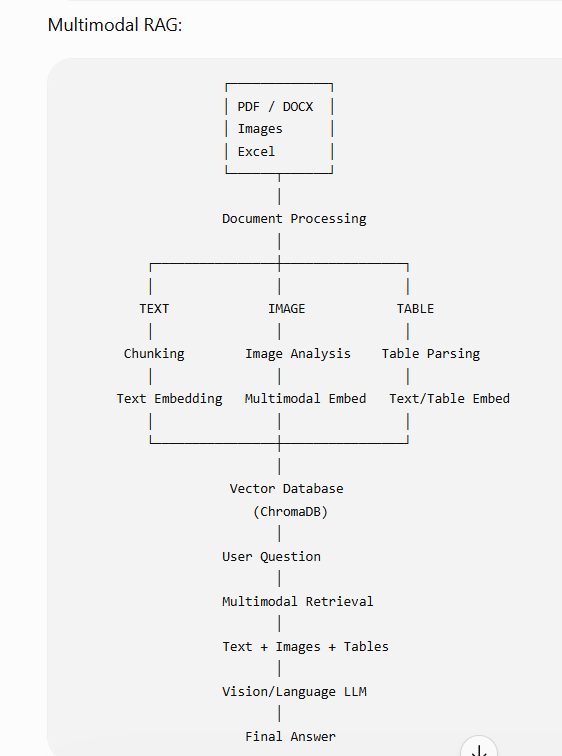

## 1. Install Python dependencies

Everything here is free and open-source — no API keys.

In [30]:
3+3

6

In [31]:
# These are also listed in requirements.txt (already installed if you followed the

#!pip install -q pymupdf pdfplumber sentence-transformers faiss-cpu pillow requests


## 2. Install & start Ollama (our local LLM/VLM engine)

Ollama lets us run open-weight language and vision models **locally on your machine** — no cloud API, no key. We install it, then start its server as a **background process** so the rest of the notebook can talk to it over `localhost:11434`.

**Install Ollama first (once per machine):**
- **macOS / Linux:** the cell below runs the official install script. You can also download the app from [ollama.com/download](https://ollama.com/download).
- **Windows:** the `curl | sh` installer doesn't apply — download and run the installer from [ollama.com/download](https://ollama.com/download) instead, then skip the install cell below and just run the "start server" cell.


In [32]:
import os
import sys

sys.path.insert(0, os.getcwd())
from src.models.providers import MultimodalProvider

GEMINI_MODEL = os.getenv("GEMINI_MODEL", "gemini-3.5-flash-lite")
OLLAMA_MODEL = os.getenv("OLLAMA_MODEL", "qwen2.5vl:3b")

provider = MultimodalProvider(
    gemini_model=GEMINI_MODEL,
    ollama_model=OLLAMA_MODEL,
)

print(f"Gemini model: {GEMINI_MODEL}")
print(f"Ollama fallback model: {OLLAMA_MODEL}")
print("Gemini API key configured:", bool(provider.gemini_api_key))
print("Set GEMINI_API_KEY in your environment before running Gemini.")

Gemini model: gemini-3.5-flash-lite
Ollama fallback model: qwen2.5vl:3b
Gemini API key configured: True
Set GEMINI_API_KEY in your environment before running Gemini.


In [33]:
# Confirm that the configured Gemini model is available for this API key.
import requests

if provider.gemini_api_key:
    try:
        models_response = requests.get(
            "https://generativelanguage.googleapis.com/v1beta/models",
            params={"key": provider.gemini_api_key, "pageSize": 100},
            timeout=30,
        )
        models_response.raise_for_status()
        available_models = {
            model["name"].removeprefix("models/")
            for model in models_response.json().get("models", [])
            if "generateContent" in model.get("supportedGenerationMethods", [])
        }

        if GEMINI_MODEL not in available_models:
            preferred_models = [
                "gemini-3.5-flash-lite",
                "gemini-3.5-flash",
                "gemini-2.5-flash",
                "gemini-2.0-flash",
            ]
            GEMINI_MODEL = next(
                (model for model in preferred_models if model in available_models),
                next(iter(available_models), GEMINI_MODEL),
            )
            provider = MultimodalProvider(
                gemini_model=GEMINI_MODEL,
                ollama_model=OLLAMA_MODEL,
            )
            print(f"Configured Gemini model was unavailable; selected: {GEMINI_MODEL}")
        else:
            print(f"Gemini model is available: {GEMINI_MODEL}")
    except requests.RequestException as error:
        print(f"Could not check Gemini models ({error}); keeping: {GEMINI_MODEL}")
else:
    print("GEMINI_API_KEY is not set; Ollama will be used.")

Gemini model is available: gemini-3.5-flash-lite


In [34]:
MODEL_NAME = OLLAMA_MODEL

# Pull the local fallback once. Gemini is used first when GEMINI_API_KEY is set.
!ollama pull {OLLAMA_MODEL}

pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest 
pulling e9758e589d44: 100% ▕██████████████████▏ 3.2 GB                         
pulling a242d8dfdc8f: 100% ▕██████████████████▏  487 B                         
pulling 75357d685f23: 100% ▕██████████████████▏   28 B                         
pulling 832dd9e00a68: 100% ▕██████████████████▏  11 KB                         
pulling 52d2a7aa3a38: 100% ▕██████████████████▏   23 B                         
pulling 97a23b280c2e: 100% ▕██████████████████▏  567 B                         
verifying sha256 digest 
writing manifest 
success 


In [35]:
# Quick sanity check that the model responds
import requests, json

resp = requests.post("http://localhost:11434/api/chat", json={
    "model": MODEL_NAME,
    "messages": [{"role": "user", "content": "Reply with just the word: ready"}],
    "stream": False,
})
print(resp.json()["message"]["content"])

ready


## 3. Add your sample PDF

Use an **annual report / product report / business report** style PDF — ideally one with normal paragraphs, at least one table, and at least one chart or image (a company annual report works great).

Running locally in VS Code: just place your PDF at `data/sample_report.pdf` (relative to this notebook) before running the cell below — there's no file-picker popup like in Colab, so the cell will detect there's no upload widget and tell you to place the file manually.


## 4. Content Extraction

This is the stage that's genuinely new compared to text-only RAG. We pull **three different kinds of content** out of the same PDF, each with its own extraction tool:

| Content type | Tool | Why this tool |
|---|---|---|
| Paragraph text | PyMuPDF (`fitz`) | Fast, reliable text extraction with page numbers |
| Tables | `pdfplumber` | Detects table grid structure that plain text extraction would mangle |
| Images / charts | PyMuPDF (`fitz`) | Can pull embedded images directly from the PDF's internal structure |

**Expected output of this stage:** three Python lists — `text_docs`, `table_docs`, `image_docs` — each holding raw content plus its page number.

In [36]:
import fitz  # PyMuPDF

text_docs = []  # [{"page": int, "text": str}]
PDF_PATH="data/uploads/Rag_research_paper.pdf"

pdf = fitz.open(PDF_PATH)
for page_num, page in enumerate(pdf, start=1):
    text = page.get_text().strip()
    if text:
        text_docs.append({"page": page_num, "text": text})

print(f"Extracted text from {len(text_docs)} pages.")
print("--- Preview of page 1 ---")
print(text_docs[3]["text"][:400] if text_docs else "(no text found)")

Extracted text from 21 pages.
--- Preview of page 1 ---
4
Fig. 3.
Comparison between the three paradigms of RAG. (Left) Naive RAG mainly consists of three parts: indexing, retrieval and generation. (Middle)
Advanced RAG proposes multiple optimization strategies around pre-retrieval and post-retrieval, with a process similar to the Naive RAG, still following a
chain-like structure. (Right) Modular RAG inherits and develops from the previous paradigm, sh


## 3 tables and 6 images

In [37]:
import pdfplumber

PDF_PATH = "data/uploads/Rag_research_paper.pdf"

table_docs = []

table_settings = {
    "vertical_strategy": "text",
    "horizontal_strategy": "text",

    "explicit_vertical_lines": [],
    "explicit_horizontal_lines": [],

    "snap_tolerance": 5,
    "join_tolerance": 5,
    "edge_min_length": 3,

    "min_words_vertical": 3,
    "min_words_horizontal": 1,

    "intersection_tolerance": 5,

    "text_tolerance": 3,
}


with pdfplumber.open(PDF_PATH) as pdf:

    for page_num, page in enumerate(pdf.pages, start=1):

        print(f"\nProcessing Page {page_num}...")

        tables = page.extract_tables(table_settings)

        print(f"Tables found: {len(tables)}")

        for table_index, table in enumerate(tables, start=1):

            if not table:
                continue

            # Remove completely empty rows
            cleaned_table = []

            for row in table:

                if row is None:
                    continue

                cleaned_row = [
                    str(cell).replace("\n", " ").strip()
                    if cell else ""
                    for cell in row
                ]

                if any(cleaned_row):
                    cleaned_table.append(cleaned_row)

            if len(cleaned_table) < 2:
                continue

            # Convert table to Markdown
            header = cleaned_table[0]
            rows = cleaned_table[1:]

            markdown_lines = []

            markdown_lines.append(
                "| " + " | ".join(header) + " |"
            )

            markdown_lines.append(
                "| " + " | ".join(["---"] * len(header)) + " |"
            )

            for row in rows:

                # Make sure row length matches header
                while len(row) < len(header):
                    row.append("")

                row = row[:len(header)]

                markdown_lines.append(
                    "| " + " | ".join(row) + " |"
                )

            markdown_table = "\n".join(markdown_lines)

            table_docs.append({
                "page": page_num,
                "table_index": table_index,
                "markdown": markdown_table
            })


print("\n" + "=" * 60)
print(f"TOTAL TABLES EXTRACTED: {len(table_docs)}")
print("=" * 60)


# Preview
for table in table_docs:

    print(f"\nPAGE: {table['page']}")
    print(f"TABLE: {table['table_index']}")

    print(table["markdown"][:1000])


Processing Page 1...
Tables found: 1

Processing Page 2...
Tables found: 1

Processing Page 3...
Tables found: 1

Processing Page 4...
Tables found: 1

Processing Page 5...
Tables found: 1

Processing Page 6...
Tables found: 1

Processing Page 7...
Tables found: 1

Processing Page 8...
Tables found: 1

Processing Page 9...
Tables found: 1

Processing Page 10...
Tables found: 1

Processing Page 11...
Tables found: 1

Processing Page 12...
Tables found: 1

Processing Page 13...
Tables found: 1

Processing Page 14...
Tables found: 1

Processing Page 15...
Tables found: 1

Processing Page 16...
Tables found: 1

Processing Page 17...
Tables found: 1

Processing Page 18...
Tables found: 1

Processing Page 19...
Tables found: 1

Processing Page 20...
Tables found: 1

Processing Page 21...
Tables found: 1

TOTAL TABLES EXTRACTED: 21

PAGE: 1
TABLE: 1
|  |  | 1 |
| --- | --- | --- |
|  | Retrieval-Augmented | Generation for Large |
|  | Language Mod | els: A Survey |
|  | Yunfan Gaoa, Yun Xion

In [38]:
import fitz
import os


# ==========================================
# CONFIGURATION
# ==========================================
PDF_PATH = "data/uploads/Rag_research_paper.pdf"
OUTPUT_DIR = "data/extracted_images"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ==========================================
# OPEN PDF
# ==========================================

pdf = fitz.open(PDF_PATH)


# ==========================================
# EXTRACT IMAGES
# ==========================================

image_docs = []

img_counter = 0


for page_num, page in enumerate(pdf, start=1):

    print(f"Processing Page {page_num}...")

    images = page.get_images(full=True)

    for img in images:

        xref = img[0]

        try:

            base_image = pdf.extract_image(xref)

            img_bytes = base_image["image"]

            ext = base_image["ext"]

            img_counter += 1

            img_path = os.path.join(
                OUTPUT_DIR,
                f"page{page_num}_img{img_counter}.{ext}"
            )

            # Save image
            with open(img_path, "wb") as f:
                f.write(img_bytes)

            image_docs.append({
                "page": page_num,
                "image_id": img_counter,
                "xref": xref,
                "path": img_path,
                "extension": ext
            })

            print(f"Extracted: {img_path}")

        except Exception as e:

            print(
                f"Failed extracting image "
                f"from page {page_num}: {e}"
            )


# ==========================================
# CLOSE PDF
# ==========================================

pdf.close()


# ==========================================
# RESULTS
# ==========================================

print("\n" + "=" * 50)

print(
    f"TOTAL IMAGES EXTRACTED: "
    f"{len(image_docs)}"
)

print("=" * 50)


for d in image_docs:

    print(
        f"Page {d['page']} → "
        f"{d['path']}"
    )

Processing Page 1...
Processing Page 2...
Extracted: data/extracted_images\page2_img1.png
Processing Page 3...
Extracted: data/extracted_images\page3_img2.png
Processing Page 4...
Extracted: data/extracted_images\page4_img3.png
Processing Page 5...
Processing Page 6...
Processing Page 7...
Extracted: data/extracted_images\page7_img4.png
Processing Page 8...
Processing Page 9...
Processing Page 10...
Processing Page 11...
Extracted: data/extracted_images\page11_img5.png
Processing Page 12...
Processing Page 13...
Processing Page 14...
Processing Page 15...
Processing Page 16...
Extracted: data/extracted_images\page16_img6.png
Processing Page 17...
Processing Page 18...
Processing Page 19...
Processing Page 20...
Processing Page 21...

TOTAL IMAGES EXTRACTED: 6
Page 2 → data/extracted_images\page2_img1.png
Page 3 → data/extracted_images\page3_img2.png
Page 4 → data/extracted_images\page4_img3.png
Page 7 → data/extracted_images\page7_img4.png
Page 11 → data/extracted_images\page11_img5.pn

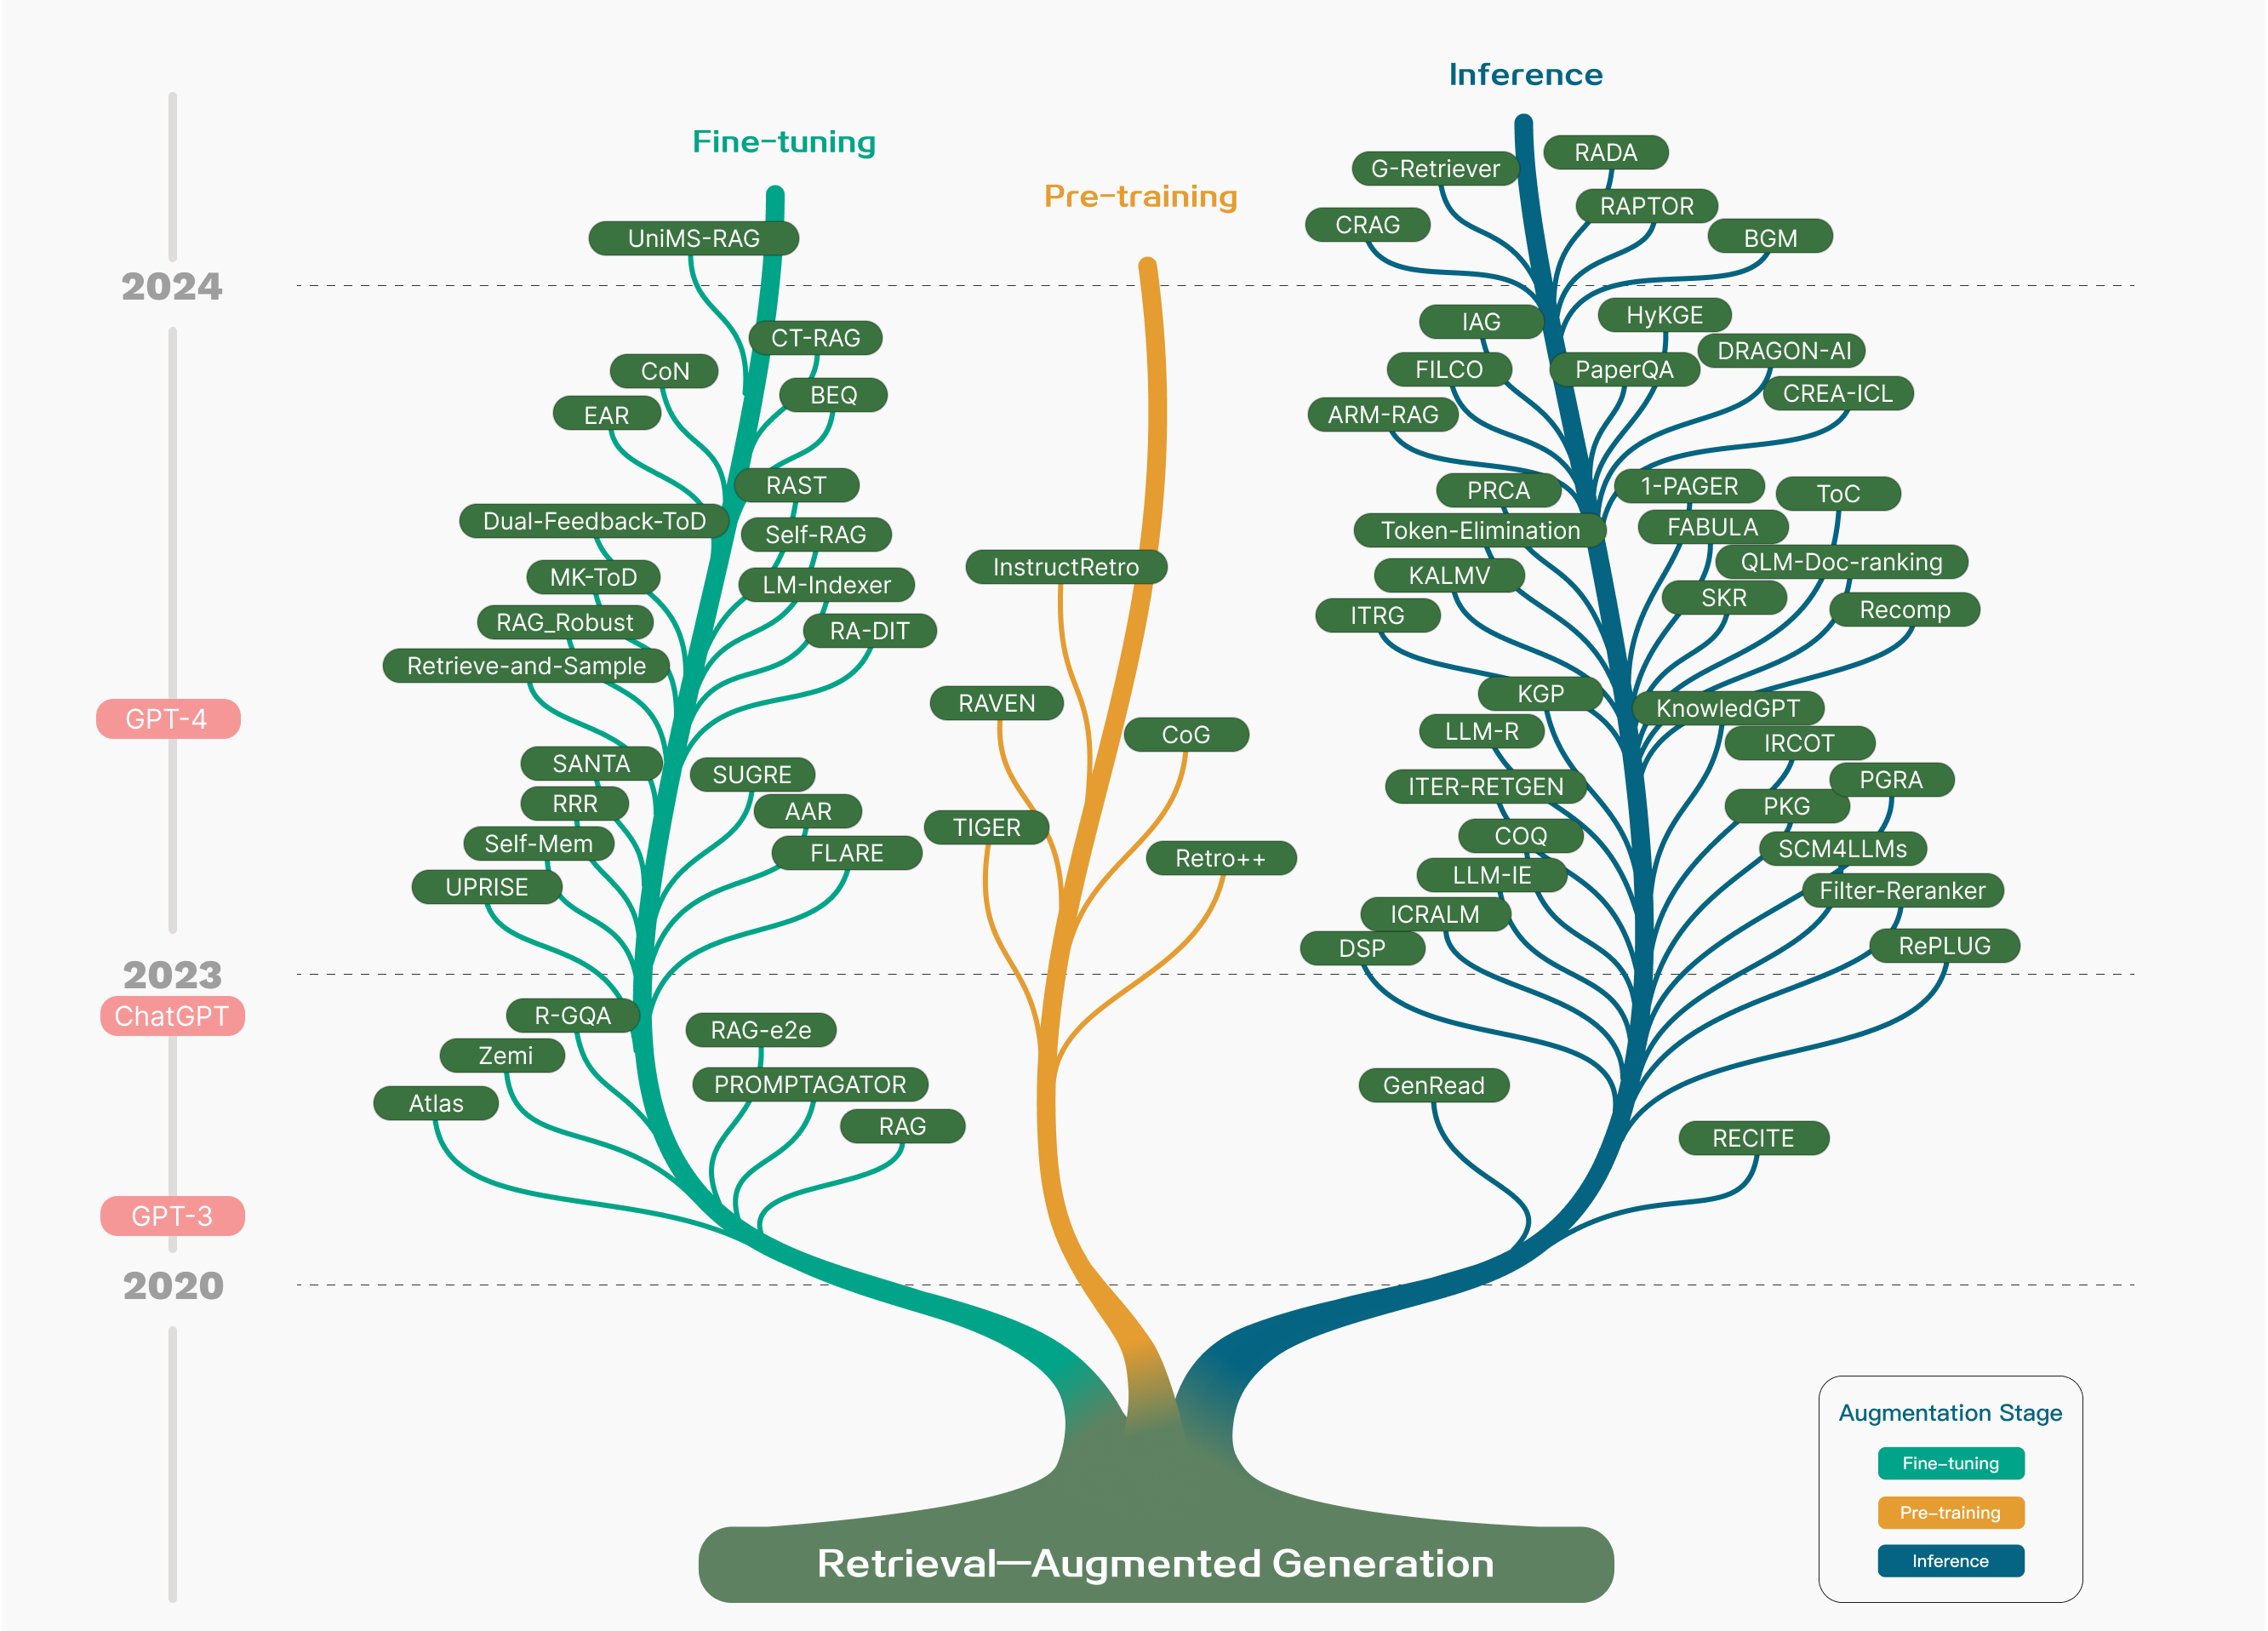

Extracted from page 2: data/extracted_images\page2_img1.png


In [39]:
# Take a quick look at one extracted image without importing Matplotlib.
from IPython.display import Image as IPImage, display

if image_docs:
    image_path = image_docs[0]["path"]
    display(IPImage(filename=image_path))
    print(f"Extracted from page {image_docs[0]['page']}: {image_path}")
else:
    print("No images found in this PDF - try a report that includes a chart/diagram.")

## 5. Chunking (text only — tables & images are already the right size)

Same idea as basic RAG: long text needs to be split into small, retrievable pieces. Tables and images are naturally already 'one unit', so we don't chunk those — a whole table or a whole image becomes one retrievable item.

In [40]:
def chunk_text(text, chunk_size=600, overlap=100):
    """Simple sliding-window chunker on characters."""
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap
    return chunks

text_chunks = []  # [{"page": int, "text": str}]
for doc in text_docs:
    for chunk in chunk_text(doc["text"]):
        if chunk.strip():
            text_chunks.append({"page": doc["page"], "text": chunk})

print(f"Created {len(text_chunks)} text chunks from {len(text_docs)} pages.")

Created 229 text chunks from 21 pages.


## 6. Turn images into text (captioning with the local VLM)

This is the multimodal-specific step: we ask the VLM to describe each extracted image/chart in a sentence or two, so it can be embedded and searched **the same way as text**. The original image file path is kept in the metadata so we can show the VLM the *real* image later, at answer time.

In [41]:
def caption_image(path, page):
    prompt = (
        f"This image is from page {page} of a business report. "
        "Describe what it shows in 1-2 factual sentences. "
        "Mention the chart type, important values, trends, "
        "or diagram content if visible. Do not guess."
    )

    if not provider.gemini_api_key:
        print("Gemini is unavailable: GEMINI_API_KEY is not set. Using Ollama.")
    else:
        try:
            caption = provider._generate_gemini(prompt, [path])
            provider.last_provider = "gemini"
            print("Caption generated with Gemini.")
            return caption
        except Exception as error:
            print(f"Gemini captioning failed ({error}); using Ollama fallback.")

    caption = provider._generate_ollama(prompt, [path])
    provider.last_provider = "ollama"
    print("Caption generated with Ollama.")
    return caption

In [42]:
print(MODEL_NAME)

qwen2.5vl:3b


In [43]:
image_captions = []

for doc in image_docs:

    caption = caption_image(
        doc["path"],
        doc["page"]
    )

    image_captions.append({
        "page": doc["page"],
        "path": doc["path"],
        "caption": caption
    })

    print(f"[page {doc['page']}] {caption}")

Caption generated with Gemini.
[page 2] The image is a tree-style diagram titled "Retrieval-Augmented Generation" that maps the landscape of various RAG methods across a timeline spanning from 2020 to 2024. The branches categorize methodologies into three distinct augmentation stages: "Fine-tuning" (green), "Pre-training" (orange), and "Inference" (dark blue), with specific algorithmic models labeled on each branch.
Caption generated with Gemini.
[page 3] This is a process diagram illustrating a Retrieval-Augmented Generation (RAG) system workflow, comparing responses "without RAG" and "with RAG." The flowchart maps out inputs, indexing, retrieval, and generation steps, showing how external documents and vector embeddings inform an LLM to answer a user's query about OpenAI's CEO.
Caption generated with Gemini.
[page 4] This image presents a flowchart comparison of three RAG (Retrieval-Augmented Generation) architectures: Naive RAG, Advanced RAG, and Modular RAG. Each diagram outlines s

## 7. Embeddings — one shared vector space for everything

We now embed **text chunks**, **table markdown**, and **image captions** using the *same* Sentence-Transformers model. This is exactly the embedding step from basic RAG — nothing new here, which is the point: multimodal content just needs to be turned into text-like representations *before* this step.

In [45]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedder = SentenceTransformer("all-MiniLM-L6-v2")

# metadata[i] describes what vectors[i] represents
metadata = []
texts_to_embed = []

for c in text_chunks:
    metadata.append({"type": "text", "page": c["page"], "content": c["text"], "image_path": None})
    texts_to_embed.append(c["text"])

for t in table_docs:
    metadata.append({"type": "table", "page": t["page"], "content": t["markdown"], "image_path": None})
    texts_to_embed.append(t["markdown"])

for img in image_captions:
    metadata.append({"type": "image", "page": img["page"], "content": img["caption"], "image_path": img["path"]})
    texts_to_embed.append(img["caption"])

embeddings = embedder.encode(texts_to_embed, show_progress_bar=True, normalize_embeddings=True)
embeddings = np.array(embeddings).astype("float32")

print(f"Embedded {len(texts_to_embed)} items -> vectors of dimension {embeddings.shape[1]}")
print("Breakdown:", {t: sum(1 for m in metadata if m["type"] == t) for t in ["text", "table", "image"]})

Batches: 100%|██████████| 8/8 [00:06<00:00,  1.17it/s]

Embedded 256 items -> vectors of dimension 384
Breakdown: {'text': 229, 'table': 21, 'image': 6}


## 8. Build the FAISS vector store

Identical to basic text RAG — FAISS doesn't know or care that some of these vectors originally came from an image. That's exactly why the captioning trick in Step 6 is useful.

In [46]:
import faiss

dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # inner product on normalized vectors = cosine similarity
index.add(embeddings)

print(f"FAISS index built with {index.ntotal} vectors.")

FAISS index built with 256 vectors.


## 9. Retriever

Same retrieval function you already know from basic RAG. It returns whichever content type is most relevant — text, table, or image — the retriever doesn't need to know the difference.

In [47]:
def retrieve(query, k=3):
    query_vec = embedder.encode([query], normalize_embeddings=True).astype("float32")
    scores, indices = index.search(query_vec, k)
    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx == -1:
            continue
        item = dict(metadata[idx])
        item["score"] = float(score)
        results.append(item)
    return results

# Quick test
for r in retrieve("revenue", k=3):
    print(f"[{r['type']}] page {r['page']} (score={r['score']:.2f}) -> {r['content'][:80]}...")

[text] page 21 (score=0.21) -> 3, pp.
2450–2462....
[image] page 16 (score=0.18) -> This business report graphic, titled "RAG Ecosystem," maps out the components of...
[image] page 3 (score=0.17) -> This is a process diagram illustrating a Retrieval-Augmented Generation (RAG) sy...


## 10. Multimodal generation — assembling context and calling the VLM

This is where multimodal RAG diverges from text RAG at the *generation* stage:

- Retrieved **text** and **table** items are added as plain text context in the prompt (same as basic RAG).
- Retrieved **image** items are sent to the VLM as an **actual image**, not just their caption — so the model can really look at the chart/diagram before answering.

**Expected output:** a natural-language answer, plus a printout of which chunks (and their type) were used — useful for explaining *why* the model answered the way it did.

In [48]:
from hashlib import sha256
from pathlib import Path
from IPython.display import display, Image as IPImage


def display_image(path, page=None, label="Image"):
    page_label = f" from page {page}" if page is not None else ""
    print(f"\n{label}{page_label}: {path}")
    display(IPImage(filename=path))


def generate_answer(query, k=3, verbose=True):
    results = retrieve(query, k=k)
    text_context = []
    image_paths = []

    for result in results:
        if result["type"] in ("text", "table"):
            text_context.append(
                f"[Page {result['page']}, {result['type']}]\n{result['content']}"
            )
        elif result["type"] == "image":
            text_context.append(
                f"[Page {result['page']}, image]\nCaption: {result['content']}"
            )
            image_paths.append(result["image_path"])

    if verbose:
        print("=" * 70)
        print("RETRIEVED SOURCES")
        print("=" * 70)
        for number, result in enumerate(results, start=1):
            print(
                f"{number}. Type: {result['type']} | Page: {result['page']} | "
                f"Score: {result['score']:.4f}"
            )
        for result in results:
            if result["type"] == "image":
                display_image(result["image_path"], result["page"], "PDF image")

    context_block = "\n\n".join(text_context)
    prompt = (
        "You are answering a question about a business report.\n\n"
        "Use ONLY the provided text context and attached images. "
        "If the answer is not available, say so. Do not invent values, dates, "
        "names, or relationships.\n\n"
        f"Context:\n{context_block}\n\nQuestion: {query}"
    )

    print("\n" + "=" * 70)
    print("ASKING GEMINI (Ollama fallback if unavailable or quota is exhausted)")
    print("=" * 70)
    answer = provider.generate(prompt, image_paths=image_paths)
    print(f"Provider used: {provider.last_provider}")

    generated_image_path = (
        Path("data/generated_images")
        / f"answer_{sha256(query.encode('utf-8')).hexdigest()[:12]}.png"
    )
    image_prompt = (
        "Create a super-clear, accurate educational illustration that helps explain "
        "the answer below. Base it on the question and answer, not on copying any "
        "image from the source PDF. Use a clean professional infographic or diagram "
        "style, strong visual hierarchy, readable labels only when essential, and "
        "avoid decorative or ambiguous details. Do not add facts that are absent from "
        "the answer.\n\n"
        f"Question: {query}\n\nAnswer: {answer}"
    )
    try:
        provider.generate_image(image_prompt, generated_image_path)
        display_image(generated_image_path, label="Generated answer image")
    except Exception as exc:
        print(f"Image generation failed: {exc}")

    if verbose:
        print("\n" + "=" * 70)
        print("ANSWER")
        print("=" * 70)
        print(answer)
    return answer

## 11. Classroom demo questions

Run each cell and discuss which content type the retriever pulled from.

In [49]:
generate_answer("What does the document say about the company's revenue?")

RETRIEVED SOURCES
1. Type: text | Page: 21 | Score: 0.2690
2. Type: table | Page: 15 | Score: 0.1683
3. Type: text | Page: 8 | Score: 0.1628

ASKING GEMINI (Ollama fallback if unavailable or quota is exhausted)
Provider used: gemini
Image generation failed: 'MultimodalProvider' object has no attribute 'generate_image'

ANSWER
Based on the provided text context and images, there is no mention of the company's revenue.


"Based on the provided text context and images, there is no mention of the company's revenue."

In [50]:
generate_answer("how rag working?")

RETRIEVED SOURCES
1. Type: text | Page: 1 | Score: 0.6945
2. Type: text | Page: 1 | Score: 0.6616
3. Type: text | Page: 2 | Score: 0.6248

ASKING GEMINI (Ollama fallback if unavailable or quota is exhausted)
Provider used: gemini
Image generation failed: 'MultimodalProvider' object has no attribute 'generate_image'

ANSWER
Based on the provided text, the RAG (Retrieval-Augmented Generation) process involves the following:

* **Core Stages:** The RAG process consists of three core stages: “Retrieval,” “Generation,” and “Augmentation.” Central technologies integral to these aspects collaborate to form a cohesive and effective RAG framework.
* **Purpose:** It provides better information for LLMs to answer more complex and knowledge-intensive tasks during the inference stage. 
* **Evolution/Integration:** Its enhancement was initially focused on the inference stage, but research has also begun to incorporate more fine-tuning techniques with LLMs. 
* **Paradigms:** Research identifies diffe

'Based on the provided text, the RAG (Retrieval-Augmented Generation) process involves the following:\n\n* **Core Stages:** The RAG process consists of three core stages: “Retrieval,” “Generation,” and “Augmentation.” Central technologies integral to these aspects collaborate to form a cohesive and effective RAG framework.\n* **Purpose:** It provides better information for LLMs to answer more complex and knowledge-intensive tasks during the inference stage. \n* **Evolution/Integration:** Its enhancement was initially focused on the inference stage, but research has also begun to incorporate more fine-tuning techniques with LLMs. \n* **Paradigms:** Research identifies different paradigms in RAG, including advanced RAG and modular RAG (summarizing three main research paradigms from over 100 RAG studies).\n\nIf you are looking for more specific technical mechanics beyond what is stated in the provided text, the answer is not available.'

RETRIEVED SOURCES
1. Type: image | Page: 7 | Score: 0.5312
2. Type: image | Page: 11 | Score: 0.4586
3. Type: image | Page: 2 | Score: 0.3957

PDF image from page 7: data/extracted_images\page7_img4.png


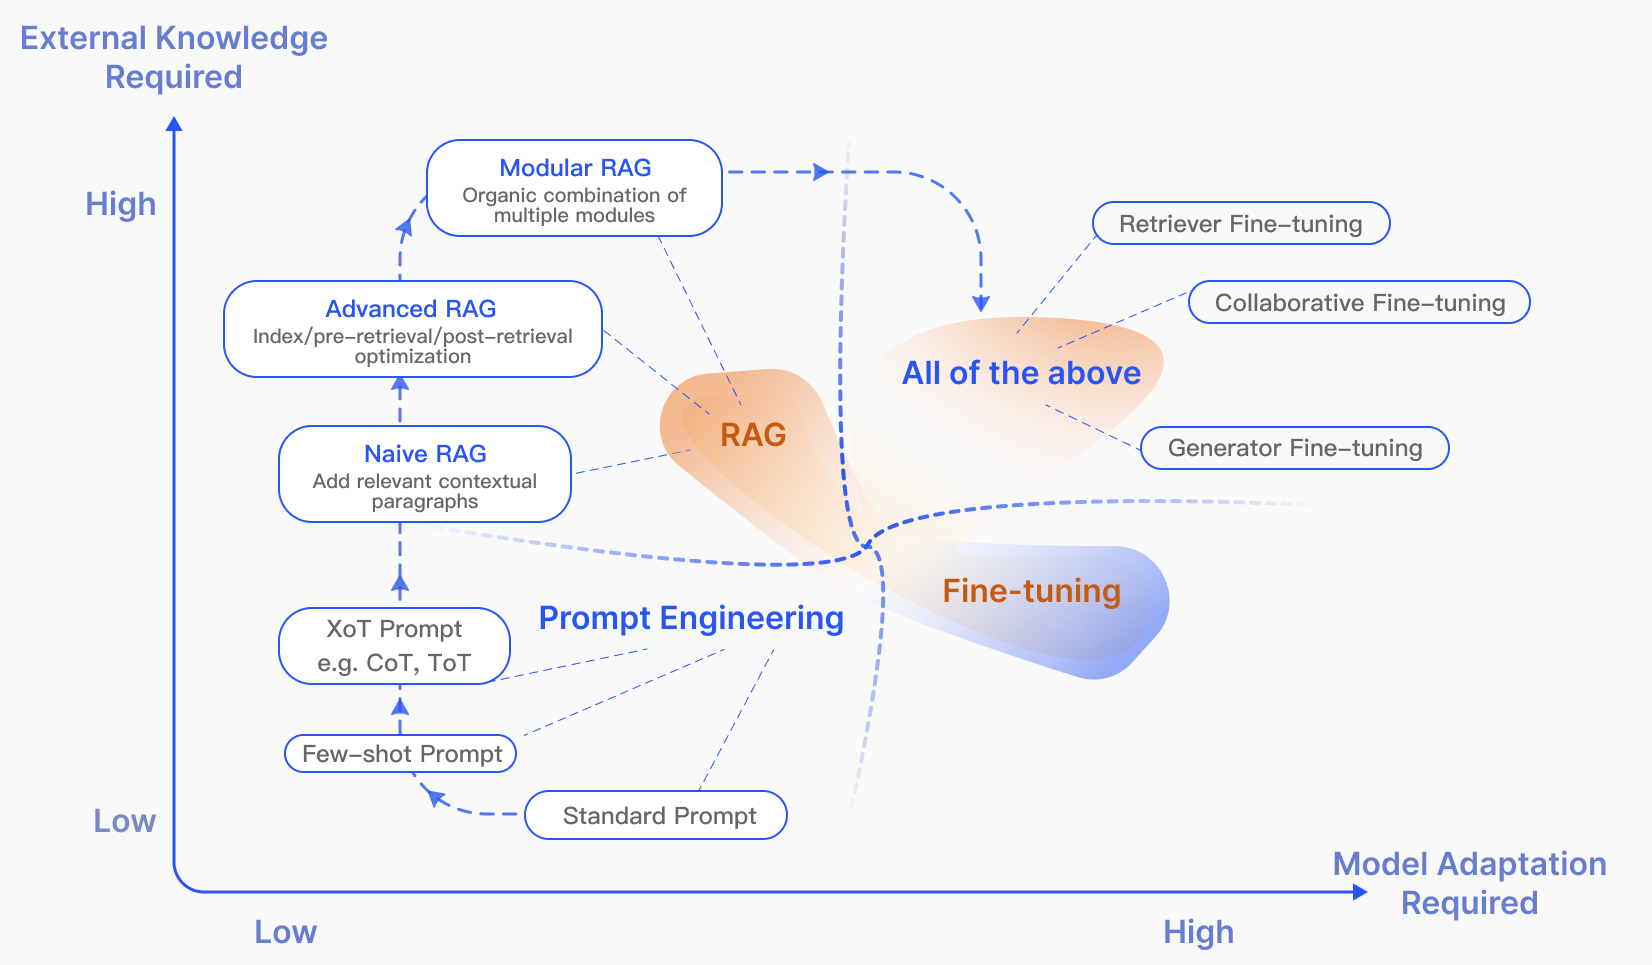


PDF image from page 11: data/extracted_images\page11_img5.png


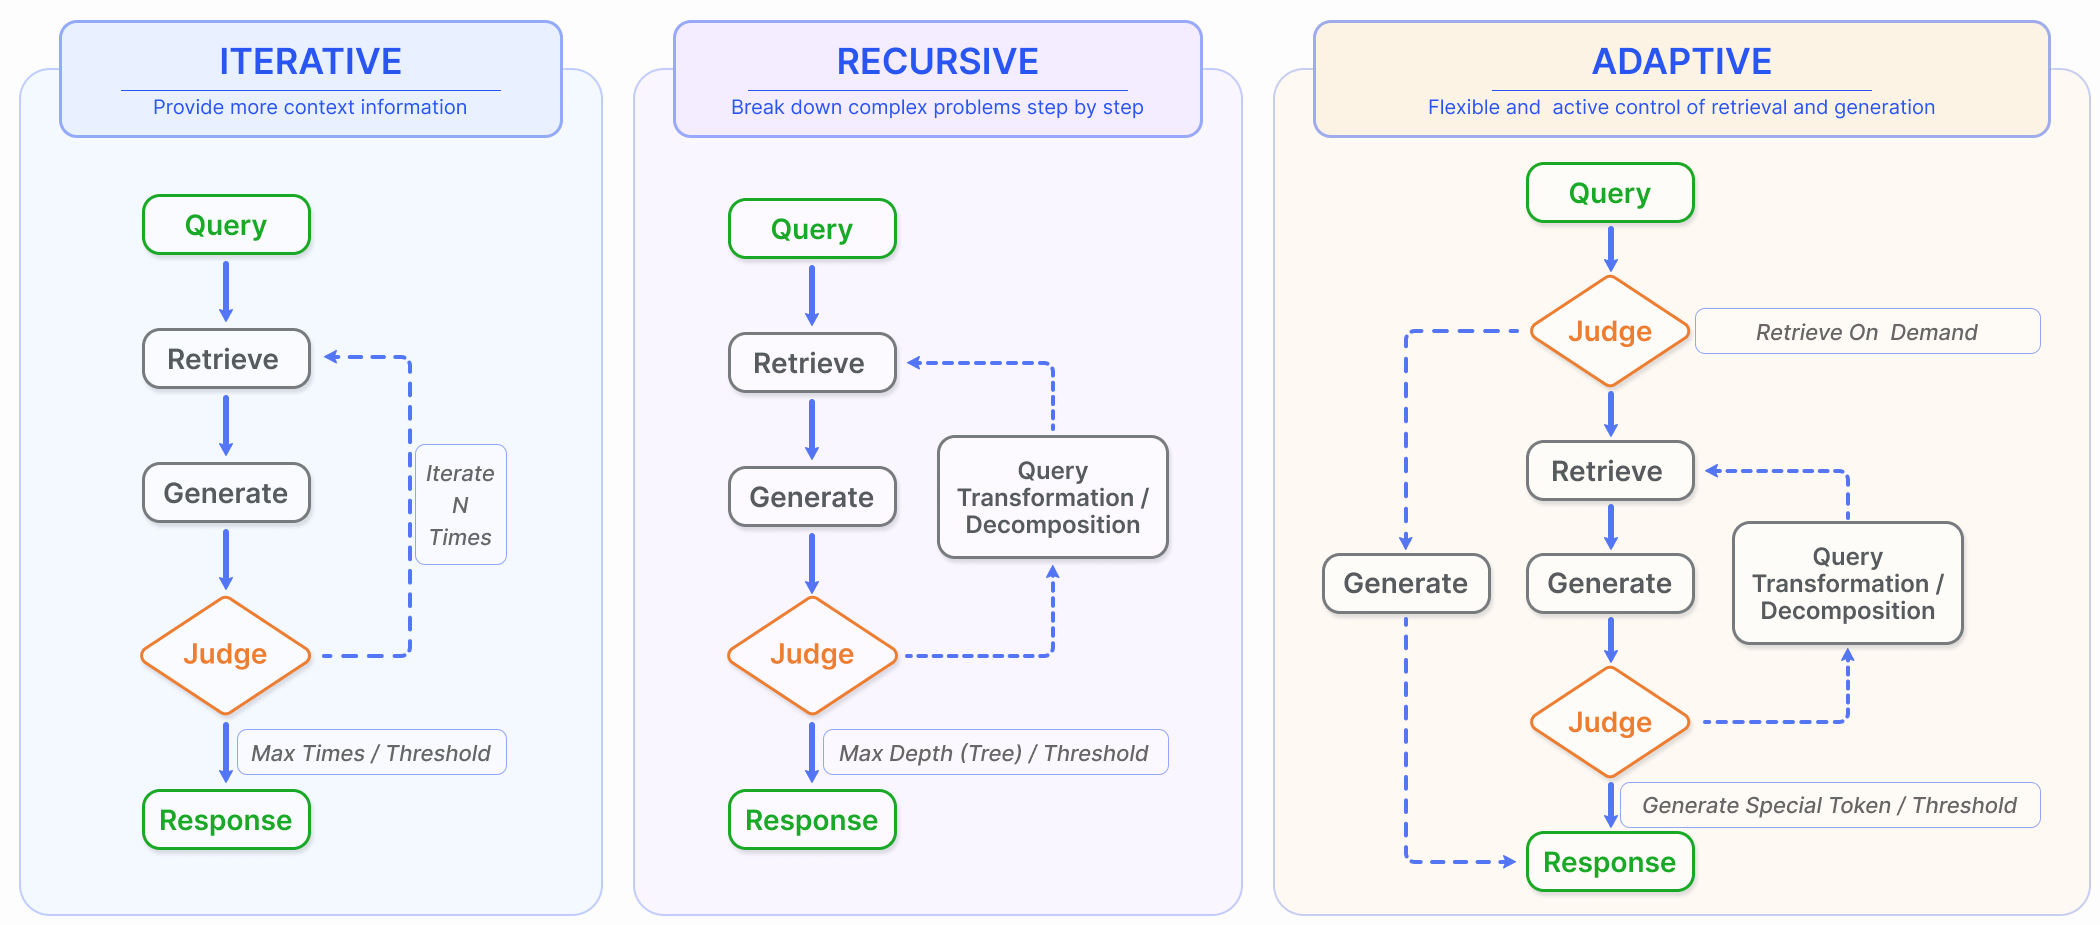


PDF image from page 2: data/extracted_images\page2_img1.png


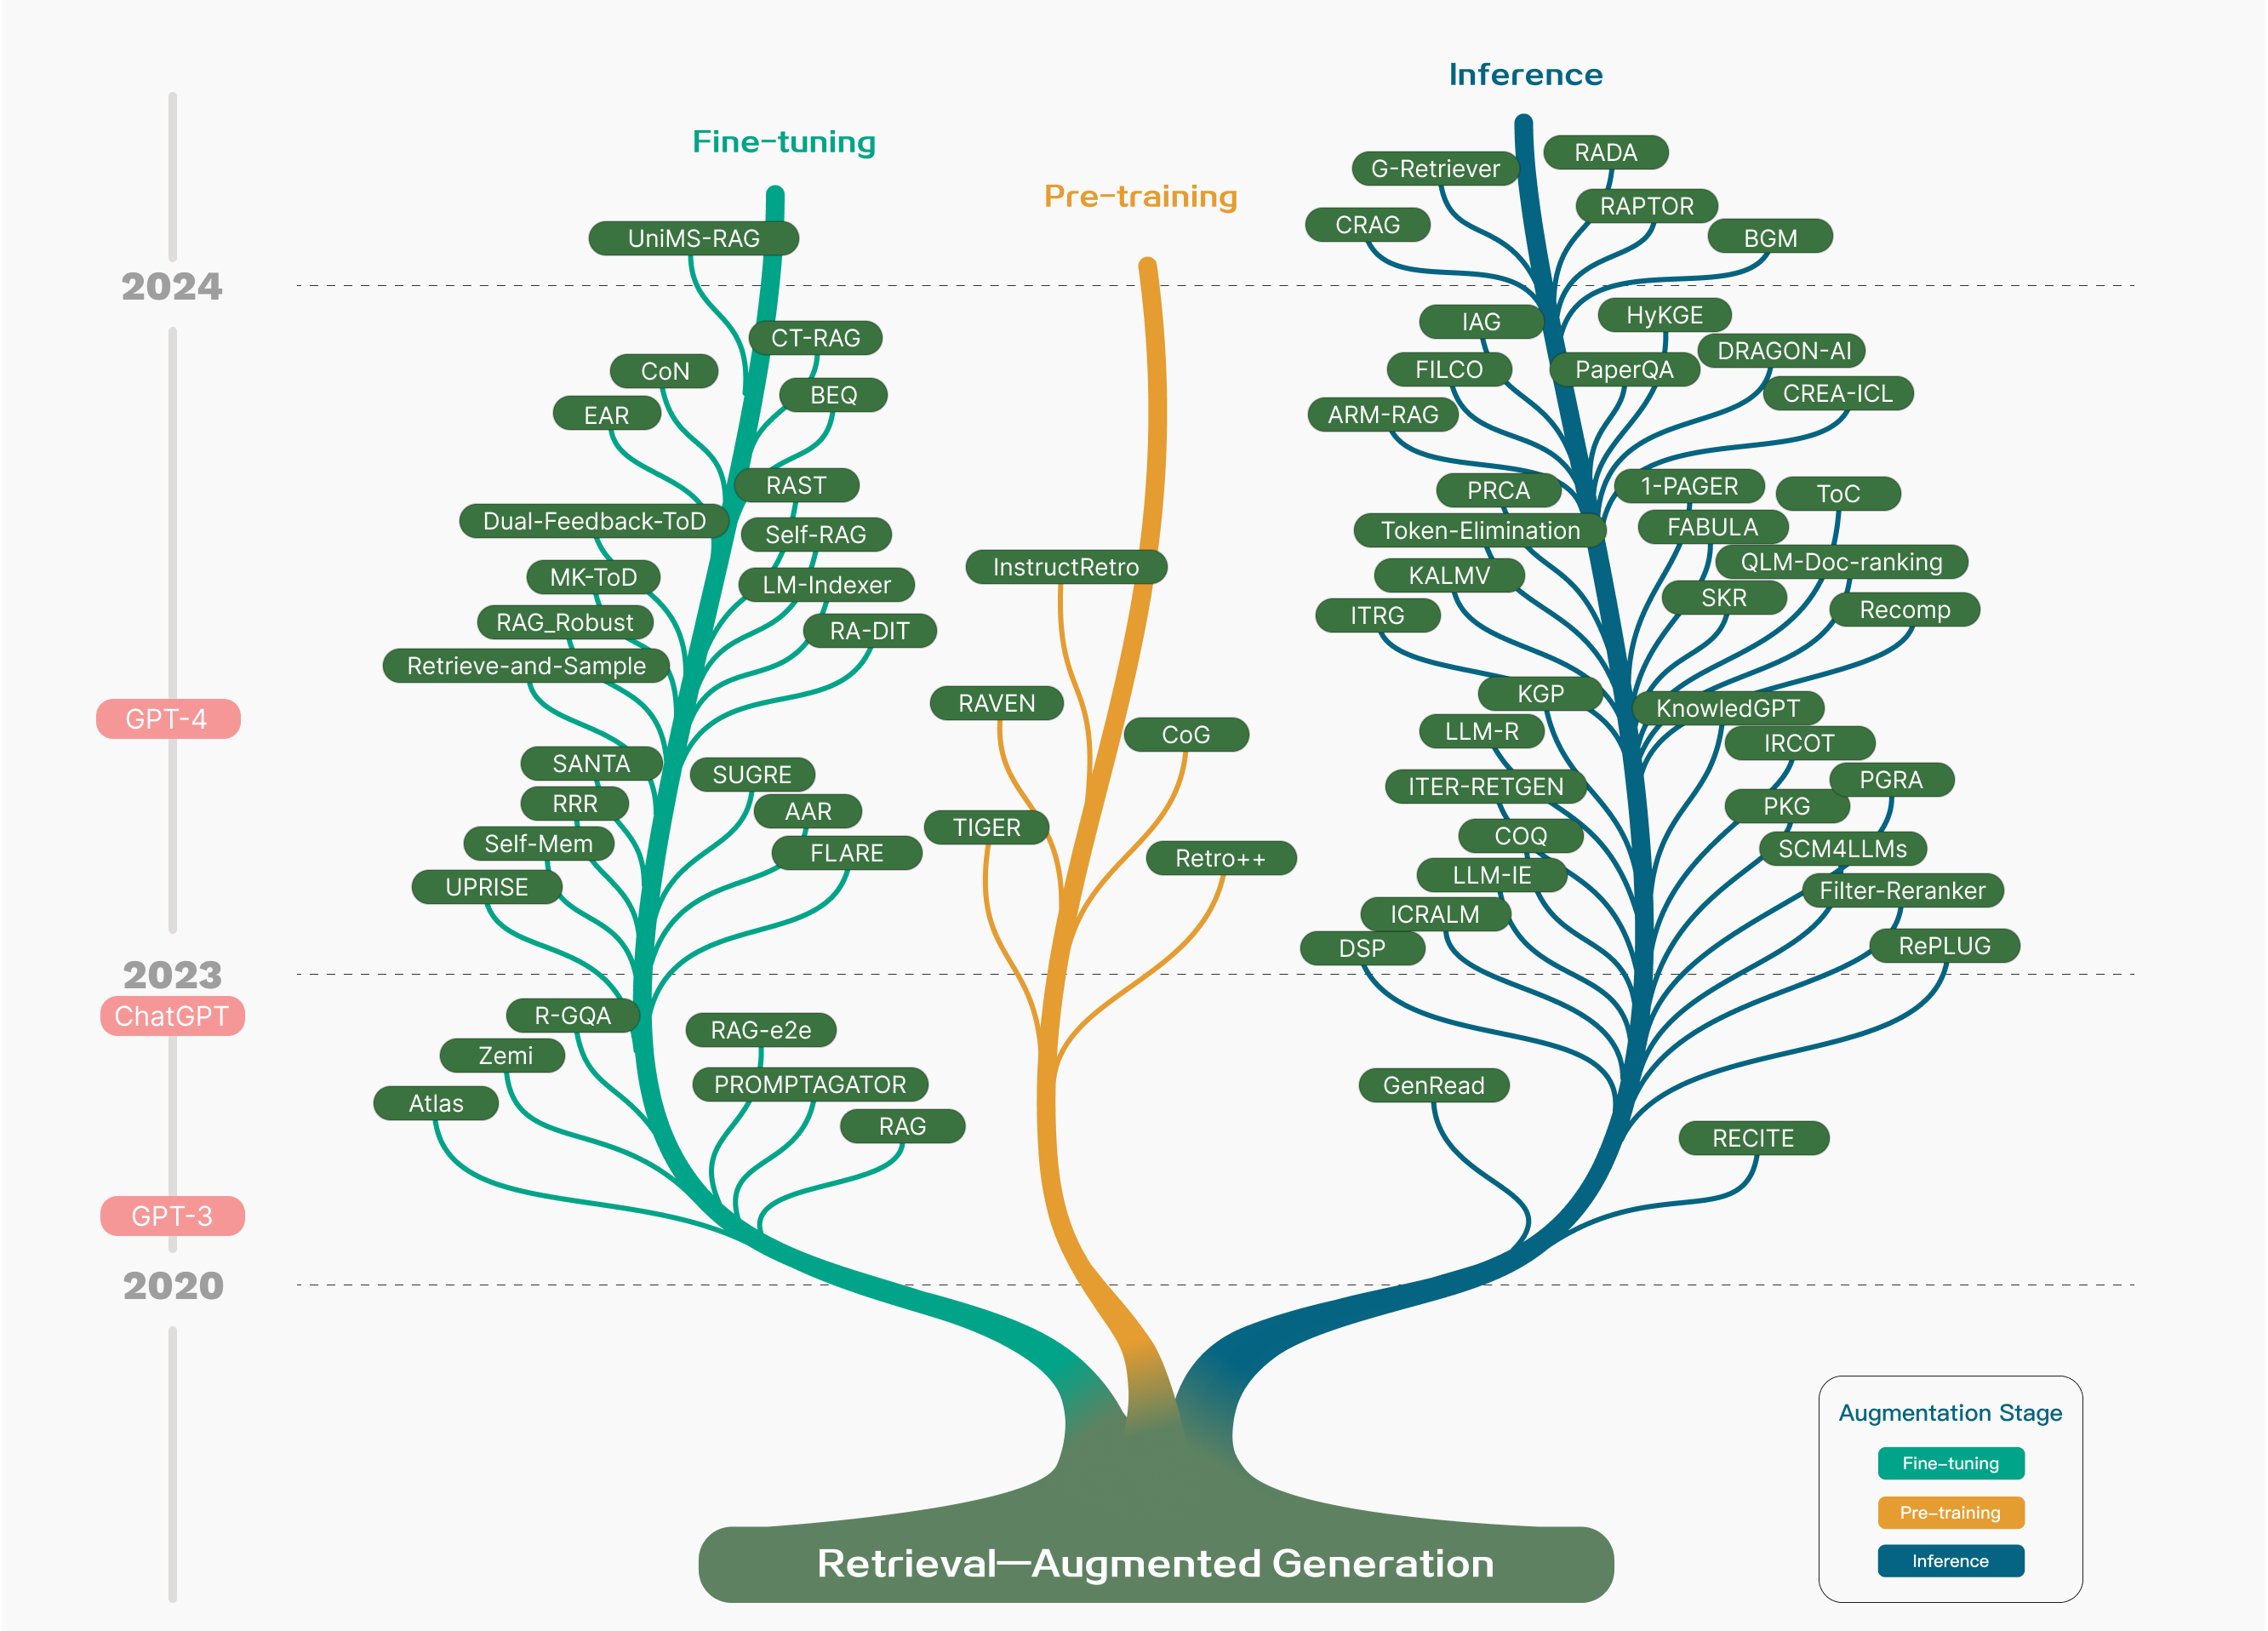


ASKING GEMINI (Ollama fallback if unavailable or quota is exhausted)
Provider used: gemini
Image generation failed: 'MultimodalProvider' object has no attribute 'generate_image'

ANSWER
Based on the provided context and images, here is the explanation for each chart or image:

* **[Page 7 image]** A scatter plot or coordinate grid titled "External Knowledge Required" (vertical axis) and "Model Adaptation Required" (horizontal axis). It maps different AI techniques such as Prompt Engineering, RAG, Fine-tuning, and All of the above, categorized by their respective levels of required external knowledge and model adaptation (ranging from Low to High).
* **[Page 11 image]** Three flowcharts labeled **Iterative**, **Recursive**, and **Adaptive**, which outline different processes for retrieval and generation starting from a query and ending with a response.
* **[Page 2 image]** A tree-style diagram titled **"Retrieval-Augmented Generation"** that maps the landscape of various RAG methods ac

'Based on the provided context and images, here is the explanation for each chart or image:\n\n* **[Page 7 image]** A scatter plot or coordinate grid titled "External Knowledge Required" (vertical axis) and "Model Adaptation Required" (horizontal axis). It maps different AI techniques such as Prompt Engineering, RAG, Fine-tuning, and All of the above, categorized by their respective levels of required external knowledge and model adaptation (ranging from Low to High).\n* **[Page 11 image]** Three flowcharts labeled **Iterative**, **Recursive**, and **Adaptive**, which outline different processes for retrieval and generation starting from a query and ending with a response.\n* **[Page 2 image]** A tree-style diagram titled **"Retrieval-Augmented Generation"** that maps the landscape of various RAG methods across a timeline spanning from 2020 to 2024. The branches categorize methodologies into three distinct augmentation stages: "Fine-tuning" (green), "Pre-training" (orange), and "Infere

In [51]:
# Adjust the page number to match a chart/image in your PDF
generate_answer("Explain the chart or image on this page.")

RETRIEVED SOURCES
1. Type: text | Page: 10 | Score: 0.5080
2. Type: image | Page: 11 | Score: 0.4134
3. Type: text | Page: 11 | Score: 0.4059

PDF image from page 11: data/extracted_images\page11_img5.png


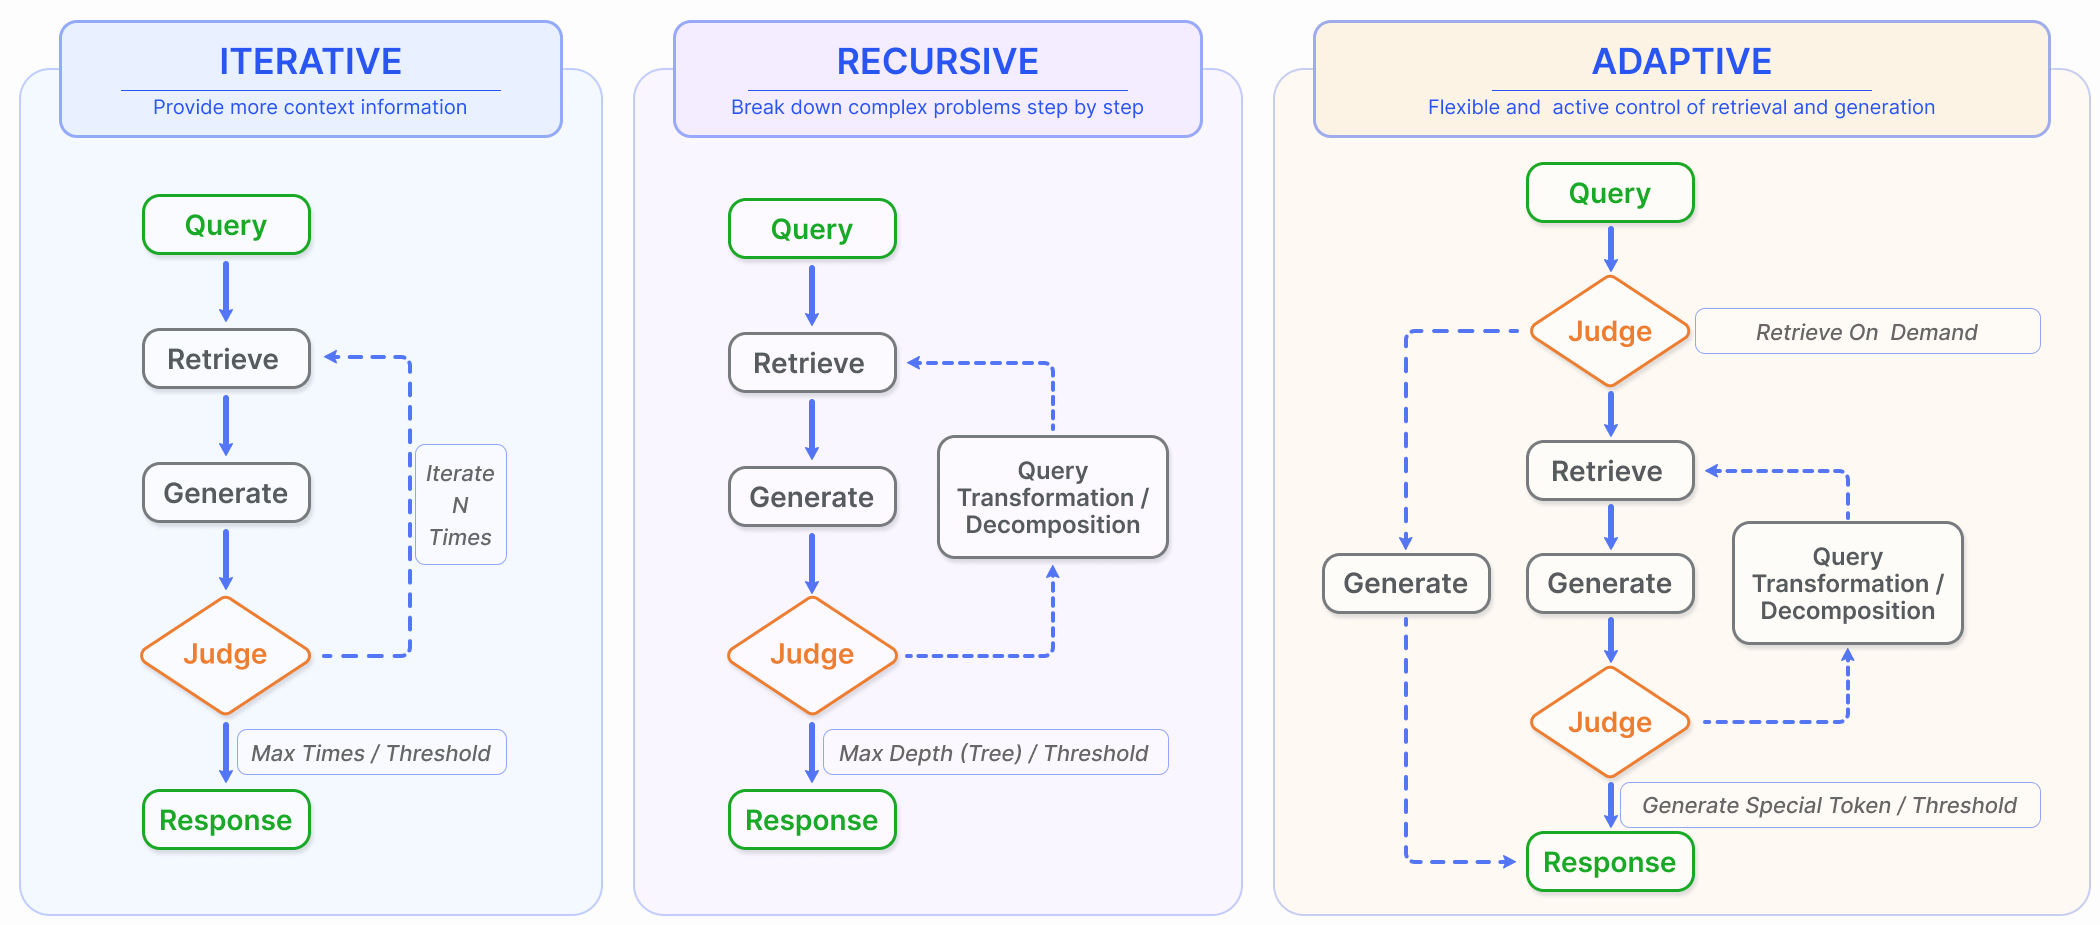


ASKING GEMINI (Ollama fallback if unavailable or quota is exhausted)
Provider used: gemini
Image generation failed: 'MultimodalProvider' object has no attribute 'generate_image'

ANSWER
Based on the provided text and image, **iterative retrieval** (or iterative process) is defined as:

* A process where the knowledge base is repeatedly searched based on the initial query and the text generated so far, providing a more comprehensive knowledge (from Page 10 text).
* Alternating between retrieval and generation, allowing for richer and more targeted context from the knowledge base at each step (from Page 11 text).
* Providing more context information, involving a loop of querying, retrieving, generating, and judging to iterate $N$ times until a max times/threshold is reached (from the Figure 5 diagram).


'Based on the provided text and image, **iterative retrieval** (or iterative process) is defined as:\n\n* A process where the knowledge base is repeatedly searched based on the initial query and the text generated so far, providing a more comprehensive knowledge (from Page 10 text).\n* Alternating between retrieval and generation, allowing for richer and more targeted context from the knowledge base at each step (from Page 11 text).\n* Providing more context information, involving a loop of querying, retrieving, generating, and judging to iterate $N$ times until a max times/threshold is reached (from the Figure 5 diagram).'

In [52]:
generate_answer("What is mean by iterative?")

In [53]:
generate_answer("what are the different types of RAG methods?")

RETRIEVED SOURCES
1. Type: text | Page: 1 | Score: 0.6178
2. Type: text | Page: 1 | Score: 0.6065
3. Type: text | Page: 4 | Score: 0.5976

ASKING GEMINI (Ollama fallback if unavailable or quota is exhausted)
Provider used: gemini
Image generation failed: 'MultimodalProvider' object has no attribute 'generate_image'

ANSWER
Based on the provided text, the three main research paradigms (or types) of RAG are:

1. **Naive RAG** (consisting mainly of indexing, retrieval, and generation)
2. **Advanced RAG** (featuring multiple optimization strategies around pre-retrieval and post-retrieval following a chain-like structure)
3. **Modular RAG** (showcasing greater flexibility through the introduction of multiple specific functional modules and the replacement of existing modules, without being limited to a sequential process)


'Based on the provided text, the three main research paradigms (or types) of RAG are:\n\n1. **Naive RAG** (consisting mainly of indexing, retrieval, and generation)\n2. **Advanced RAG** (featuring multiple optimization strategies around pre-retrieval and post-retrieval following a chain-like structure)\n3. **Modular RAG** (showcasing greater flexibility through the introduction of multiple specific functional modules and the replacement of existing modules, without being limited to a sequential process)'

## 12. Recap: what actually changed vs. basic text RAG?

| Step | Basic RAG | Multimodal RAG (today) |
|---|---|---|
| Extraction | Text only | Text + tables + images, each with its own extractor |
| Representation | Text chunks | Text chunks + table-as-markdown + image captions |
| Embedding | Sentence-Transformers | **Same** — one shared model, one shared index |
| Vector store | FAISS | **Same** |
| Retrieval | Top-k similarity search | **Same** |
| Generation | Text-only LLM call | VLM call — real image attached when an image chunk is retrieved |

The retrieval *engine* barely changed. Almost all the new work is in **extraction** (getting each content type out cleanly) and **generation** (giving the model the real image, not just a caption, when it matters).

## 13. Optional improvements for advanced students

- **True joint embeddings**: replace the caption-then-embed trick with a CLIP-style model (e.g. `open_clip`) so images are embedded directly, without a captioning round-trip.
- **Better table understanding**: try `camelot-py` for tables with complex merged cells, or ask the VLM to answer questions directly from a *rendered image* of the table instead of markdown text.
- **Re-ranking**: add a cross-encoder re-ranker on top of the FAISS top-k results before sending context to the LLM.
- **Routing**: instead of one retriever for everything, build a lightweight classifier that decides if a question is 'about a table' vs 'about an image' vs 'general text', and biases retrieval accordingly.
- **Video extension** (not built today, but a natural next step): sample frames from a video with OpenCV every N seconds, caption each frame the same way we captioned images here, embed captions, and reuse this exact retrieval + generation pipeline. Optionally transcribe audio with a local Whisper model and treat the transcript like another text document.
- **Bigger models**: swap `MODEL_NAME` to `qwen2.5vl:7b` or `qwen2.5vl:32b` (if VRAM allows) for noticeably better chart-reading accuracy.

## 14. Troubleshooting

| Problem | Likely cause | Fix |
|---|---|---|
| `ollama: command not found` | Install cell didn't finish | Re-run the install cell, then restart runtime if needed |
| Ollama server check keeps failing | Server needs a few more seconds, or a previous process is stuck | Re-run the `subprocess.Popen` cell; if stuck, `Runtime → Restart runtime` and start over |
| `ollama pull` is slow | Colab's network speed varies | Use `qwen2.5vl:3b` (smaller) instead of 7b for a live class |
| No images extracted from PDF | Charts might be vector-drawn, not embedded raster images | Use a PDF where charts are inserted as images/screenshots, or render the page itself as an image with `page.get_pixmap()` and treat that as the 'image' for that page |
| No tables extracted | `pdfplumber` needs visible grid lines/whitespace structure | Try a PDF with a clearer bordered table, or fall back to manually typing the table text for the demo |
| CUDA / GPU errors | Runtime not set to GPU | `Runtime → Change runtime type → T4 GPU` |
| Answers ignore the image | The question didn't match the image's caption closely enough to be retrieved | Increase `k` in `generate_answer`, or ask a more specific question mentioning 'chart' or 'diagram' |

## 15. 30–40 Minute Teaching Flow

| Time | Segment |
|---|---|
| 0–5 min | Recap basic RAG diagram → introduce multimodal RAG diagram (cells 1-2) |
| 5–10 min | Setup: GPU check, installs, start Ollama, pull model (cells 3-8) — can be pre-run before class to save time |
| 10–15 min | Content extraction: run text/table/image extraction, show the raw outputs (cells 9-14) |
| 15–18 min | Chunking + image captioning — emphasize this is the 'bridge' step (cells 15-17) |
| 18–23 min | Embeddings + FAISS index — point out this is identical to what they already know (cells 18-21) |
| 23–28 min | Retrieval + multimodal generation function walkthrough (cells 22-25) |
| 28–35 min | Run all 5 demo questions live, discuss retrieved sources for each (cells 26) |
| 35–40 min | Recap table (cell 27) + optional improvements + Q&A |

**Tip:** run Steps 1–2 (installs, Ollama pull) *before* class starts so students aren't waiting on downloads during the live session.